In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the cleaned data saved by notebook 01 (no need edo cleaning here)
schools = pd.read_csv("../data/processed/schools_clean.csv")
os.makedirs("../reports/figures", exist_ok=True)   # charts get saved here for the portfolio

# Readable labels, e.g. "2-year Public"
schools["control_label"] = schools["control"].map({1: "Public", 2: "Private nonprofit"})
schools["group"] = schools["school_type"] + " " + schools["control_label"]
order = ["2-year Public", "2-year Private nonprofit", "4-year Public", "4-year Private nonprofit"]

# Clean, presentable chart defaults
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
})
print("Loaded:", schools.shape)

Matplotlib is building the font cache; this may take a moment.


Loaded: (3147, 24)


                             n   median      p25      p75
group                                                    
2-year Public              998  19708.0  16789.0  23862.0
2-year Private nonprofit   185  27354.0  21854.0  35534.0
4-year Public              565  35738.0  29785.0  43545.0
4-year Private nonprofit  1094  49718.0  34512.0  63231.0


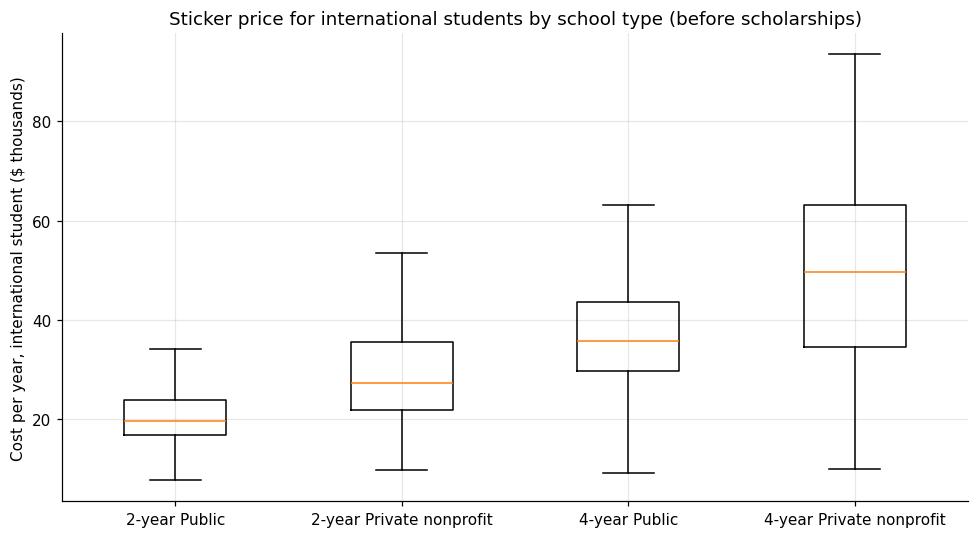

In [2]:
# Q1: What does a year cost an international student, by school type? (sticker price, BEFORE scholarships)
summary = (
    schools.groupby("group")["cost_international"]
    .agg(n="count", median="median",
         p25=lambda s: s.quantile(0.25),     # 25% of schools cost less than this
         p75=lambda s: s.quantile(0.75))     # 75% of schools cost less than this
    .reindex(order)
    .round(0)
)
print(summary)

data = [schools.loc[schools["group"] == g, "cost_international"].dropna() / 1000 for g in order]
fig, ax = plt.subplots(figsize=(9, 5))
ax.boxplot(data, showfliers=False)          # box = middle 50% of schools, line = median
ax.set_xticks(range(1, len(order) + 1))
ax.set_xticklabels(order)
ax.set_ylabel("Cost per year, international student ($ thousands)")
ax.set_title("Sticker price for international students by school type (before scholarships)")
fig.tight_layout()
fig.savefig("../reports/figures/intl_cost_by_school_type.png", dpi=200)
plt.show()

Median % international undergrads by group:
group
2-year Public               0.6
2-year Private nonprofit    0.0
4-year Public               1.8
4-year Private nonprofit    3.1
Name: pct_intl, dtype: float64


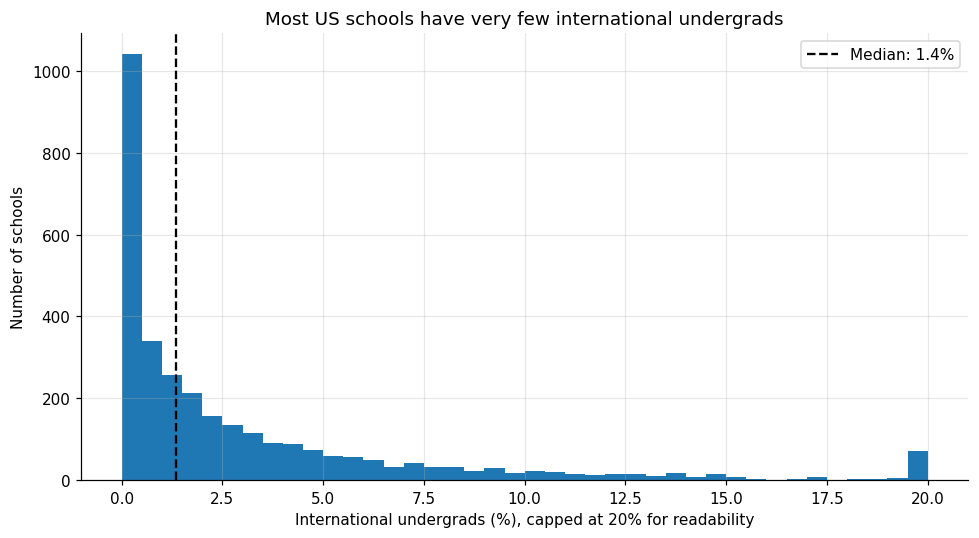


Top 10 by % international (1,000+ undergrads):
                                  name state                    group  undergrads  pct_intl  cost_international
       Brigham Young University-Hawaii    HI 4-year Private nonprofit      2889.0      61.0             25098.0
          Art Center College of Design    CA 4-year Private nonprofit      2017.0      44.1             75649.0
                        The New School    NY 4-year Private nonprofit      6563.0      34.3             88284.0
         Rhode Island School of Design    RI 4-year Private nonprofit      2084.0      33.1             81727.0
              Berklee College of Music    MA 4-year Private nonprofit      7468.0      31.9             72700.0
               Missouri Valley College    MO 4-year Private nonprofit      1443.0      28.5             37899.0
                        Babson College    MA 4-year Private nonprofit      2728.0      28.3             80192.0
School of the Art Institute of Chicago    IL 4-year Priv

In [3]:
# Q2: Where do international students already go?
schools["pct_intl"] = schools["pct_international"] * 100
print("Median % international undergrads by group:")
print(schools.groupby("group")["pct_intl"].median().reindex(order).round(1))

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(schools["pct_intl"].clip(upper=20), bins=40)   # values above 20% grouped at the right edge
ax.axvline(schools["pct_intl"].median(), linestyle="--", color="black",
           label=f"Median: {schools['pct_intl'].median():.1f}%")
ax.set_xlabel("International undergrads (%), capped at 20% for readability")
ax.set_ylabel("Number of schools")
ax.set_title("Most US schools have very few international undergrads")
ax.legend()
fig.tight_layout()
fig.savefig("../reports/figures/intl_share_distribution.png", dpi=200)
plt.show()

# Top 10 by international share, ONLY schools with 1,000+ undergrads.
# Tiny schools can hit a high % with a handful of students (small-sample trap).
big = schools[schools["undergrads"] >= 1000]
print("\nTop 10 by % international (1,000+ undergrads):")
print(big.nlargest(10, "pct_intl")[
    ["name", "state", "group", "undergrads", "pct_intl", "cost_international"]
].round(1).to_string(index=False))